# ECG — единый ноутбук: обучение на A100 и просмотр качества

Все пайплайны запускаются отсюда. По умолчанию выполняется **только короткий smoke**, полноценные запуски включаются ниже. На кластере лимита времени нет; остановка по epochs/early stopping сохраняется. Установите проект через `%pip install -e ".[dev]"` в отдельной ячейке при необходимости; CUDA PyTorch должен соответствовать кластеру. Список файлов для переноса: `docs/CLUSTER.md`.

Существующий test уже просмотрен при разработке. Здесь выбор моделей проводится только по validation; финальное независимое подтверждение требует нового контроля. Старые ноутбуки 01–03 остаются архивом исходных экспериментов.

In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
ROOT=Path.cwd()
if not (ROOT/'ecg_project').exists(): ROOT=ROOT.parent
assert (ROOT/'ecg_project').exists(), 'Укажите ROOT — корень проекта на кластере'
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
def read(p): return json.loads(Path(p).read_text(encoding='utf-8'))
print('Root:',ROOT)
print('GPU:',torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU')
VRAM=torch.cuda.get_device_properties(0).total_memory/2**30 if torch.cuda.is_available() else 0
print('VRAM GiB:',round(VRAM,1))


Root: C:\Projects\ECG


GPU: NVIDIA GeForce GTX 1050
VRAM GiB: 4.0


## 1. Управление запусками
Сначала Run All в smoke-режиме. Затем включайте нужные ветви и запускайте соответствующие ячейки. Для нового эксперимента укажите новый output. Resume продолжает последний завершённый epoch. Не запускайте несколько GPU-ветвей одновременно в разных ядрах.

In [2]:
RUN_SMOKE=True
RUN_AUDIT=False
RUN_DELINEATION=False
RUN_UNLABELED=False
RUN_BERT=False
RUN_FOUNDER=False
RUN_RECORD_CLASSIFICATION=False
PROFILE='a100_80' if VRAM>60 else 'a100_40'
RUN_DIR=Path('artifacts/cluster')
RUN_DIR.mkdir(parents=True,exist_ok=True)
print('Profile:',PROFILE)


Profile: a100_40


## 2. Данные и защита от утечек
LUDB:140/30/30 пациентов. MIT: все отведения/сокращения записи в одной части,201/202 вместе. PTB: folds1–8 train,9 valid,10 test. Georgia — внешний источник. Неразмеченные Training_2 — только pretraining. Общие метки длинной записи не заменяют эпизодные метки.

In [3]:
if RUN_AUDIT:
    from ecg_project.data.catalog import audit
    audit()
if Path('artifacts/catalog.csv').exists():
    catalog=pd.read_csv('artifacts/catalog.csv')
    display(catalog.groupby('source').agg(records=('record_id','size')))
from ecg_project.training.beats import split_for
assert split_for('201')==split_for('202')


,records
source,
LUDB,200
Training_2,3453
Training_StPetersburg,74
Training_WFDB,6877
WFDB_GEORGIA,10344
WFDB_PTB-XL,21837


## 3. Локальный smoke: forward/backward, SSL, классификация, checkpoint и resume
Одна minibatch на epoch. Полученные здесь метрики **не являются оценкой качества**. Smoke использует подготовленные MIT features, не открывает test. Для полной проверки запуска: `python -m pytest -q`.

In [4]:
from ecg_project.training.cluster_training import ClusterConfig,train_cluster
if RUN_SMOKE:
    smoke=ClusterConfig(output=str(RUN_DIR/'notebook_smoke'),dim=32,layers=1,radius=2,batch_size=16,
        accumulation=1,pretrain_epochs=1,finetune_epochs=1,max_batches=1,auto_batch=False,amp=False,gpu_resident=True)
    smoke_path=train_cluster(smoke)
    train_cluster(smoke)  # Проверка загрузки завершённого checkpoint без повторного обучения.
    display(read(smoke_path/'run.json'))


{'stage': 'pretrain', 'epoch': 1, 'loss': 1.0711805820465088, 'seconds': 4.599843800000599}


{'stage': 'finetune', 'epoch': 1, 'loss': 1.9451509714126587, 'seconds': 4.859201400000529, 'valid_score': 0.20930711595936968}


{'seconds_this_invocation': 2.866232599999421,
 'device': 'cuda',
 'parameters': 14587,
 'max_cuda_bytes': 37411328,
 'test_accessed': False,
 'smoke': True,
 'data_sha256': '272d2b3be7c80c581a8e4259a8451a1b09a0fece7c84cd37cb92245b24031c7f',
 'status': 'complete',
 'actual_batch': 16}

## 4. Разметка P/QRS/T и адаптация
Полное обучение на LUDB; consistency использует неразмеченные Training_2; QT adaptation использует только NSR часть. Внешние QT и LUDB test не участвуют в подборе. Здесь сохранены небольшие доказавшие работоспособность архитектуры; крупная модель не гарантирует лучшей точности на200 пациентах.

In [5]:
if RUN_DELINEATION:
    from ecg_project.models.segmentation import train,evaluate
    from ecg_project.training.adaptation import train as adapt
    from ecg_project.training.qtdb import train as adapt_qt
    train(epochs=100,minutes=1000000,output='artifacts/delineator.pt',device='cuda')
    adapt(epochs=40,minutes=1000000,output='artifacts/delineator_transfer.pt')
    adapt_qt(epochs=30,minutes=1000000,output='artifacts/delineator_qt.pt')
    evaluate(split='valid',checkpoint='artifacts/delineator_qt.pt',output='reports/cluster_delineation_valid.json')


## 5. Features и неразмеченные последовательности
После изменения разметчика создайте свежий каталог beat_features: старые хеши несовместимы с новыми весами. Для повтора исходного эксперимента используйте переданный cache и исходный delineator_qt.pt.

In [6]:
BEAT_ROOT='artifacts/beat_features_qt'
UNLABELED_ROOT=None
if RUN_UNLABELED:
    from ecg_project.training.unlabeled_beats import prepare
    UNLABELED_ROOT=str(prepare(output='artifacts/unlabeled_beats',limit=0,device='cuda'))
# При необходимости пересоздать MIT features:
# from ecg_project.training.beats import prepare
# prepare(output='artifacts/beat_features_new',device='cuda',checkpoint='artifacts/delineator_qt.pt')
# BEAT_ROOT='artifacts/beat_features_new'


## 6. Большой Beat-BERT: masked pretraining → fine-tuning
A100: BF16 и TF32; подбор microbatch с резервом памяти; компактные tokens находятся на GPU, окна собираются без CPU DataLoader. Attention использует PyTorch SDPA там, где backend поддерживает параметры. 40ГБ:512×8,80ГБ:768×12. Это стартовые профили, максимальная загрузка конкретной A100 локально не измерена. Проверяйте `nvidia-smi`, examples/s и память. Длина65 сокращений, PCA32+интервалы: это исследуемое ограничение представления. Для ablation задайте pretrain_epochs=0 и новый output.

In [7]:
bert_cfg=ClusterConfig(data_root=BEAT_ROOT,unlabeled_root=UNLABELED_ROOT,
    output=str(RUN_DIR/('bert_'+PROFILE)),dim=768 if PROFILE=='a100_80' else 512,
    layers=12 if PROFILE=='a100_80' else 8,radius=32,batch_size=256,auto_batch=True,
    gpu_resident=True,amp=True,pretrain_epochs=30,finetune_epochs=100,patience=15)
if RUN_BERT:
    assert VRAM>=35, 'Полный профиль предназначен для A100; для ноутбука используйте smoke.'
    train_cluster(bert_cfg)
print(bert_cfg)


ClusterConfig(data_root='artifacts/beat_features_qt', output='artifacts\\cluster\\bert_a100_40', dim=512, layers=8, radius=32, batch_size=256, accumulation=1, pretrain_epochs=30, finetune_epochs=100, learning_rate=0.0001, patience=15, workers=0, amp=True, seed=42, resume=True, max_batches=None, gpu_resident=True, auto_batch=True, unlabeled_root=None)


## 7. ECGFounder: дообучение всех30,8 млн параметров
Веса и net1d.py скачиваются официальным скриптом. Pretraining HEEDB по сведениям авторов; PTB использовался ими как внешний benchmark. HeartBERT не используется готовым, поскольку в pretraining был MIT-BIH. В этой ветке отведение I,10с,500Гц, точная предобработка ECGFounder. Полный PTB, fold10 не загружается. Начните с batch32/64; если память позволяет — увеличивайте. Gradient accumulation увеличивает effective batch, но не физическую загрузку GPU.

In [8]:
if RUN_FOUNDER:
    assert VRAM>=35
    import subprocess
    if not Path('artifacts/ecgfounder/1_lead_ECGFounder.pth').exists():
        subprocess.run([sys.executable,'-u','scripts/download_founder.py'],check=True)
    from ecg_project.experiments.founder_experiments import prepare_full_ptb
    from ecg_project.training.cluster_founder import train_founder_cluster
    full_root=Path('artifacts/founder_full_inputs')
    if not (full_root/'manifest.csv').exists(): prepare_full_ptb(str(full_root))
    train_founder_cluster(str(full_root),str(RUN_DIR/'founder_full'),epochs=100,
        batch_size=64 if PROFILE=='a100_80' else 32,workers=4,patience=15)


## 8. Классификация интервалами, сигналом и их объединением
Это отдельная baseline/ablation-ветвь. Полный корпус тяжёлый по извлечению признаков, сохраняет cache. Не меняйте split ради улучшения метрик. Проверка длинных записей ограничена слабой разметкой — см. PROJECT.md.

In [9]:
if RUN_RECORD_CLASSIFICATION:
    from ecg_project.training.record_model import prepare,train
    cache='artifacts/cluster/record_features'
    prepare(output=cache,limit=0,device='cuda',checkpoint='artifacts/delineator_qt.pt')
    train(manifest=cache+'/manifest.csv',output='artifacts/cluster/record_models',minutes=1000000)


## 9. Просмотр референсной и предсказанной разметки
Измените путь, отведение, начало и длину окна. Цветные области — предсказания, штрихованные — ручные границы. QT имеет неполную разметку; отсутствие T-onset не заполняется придуманной границей. Пример отдельной записи не является доказательством качества.

Analysis written to C:\Projects\ECG\reports\notebook_preview


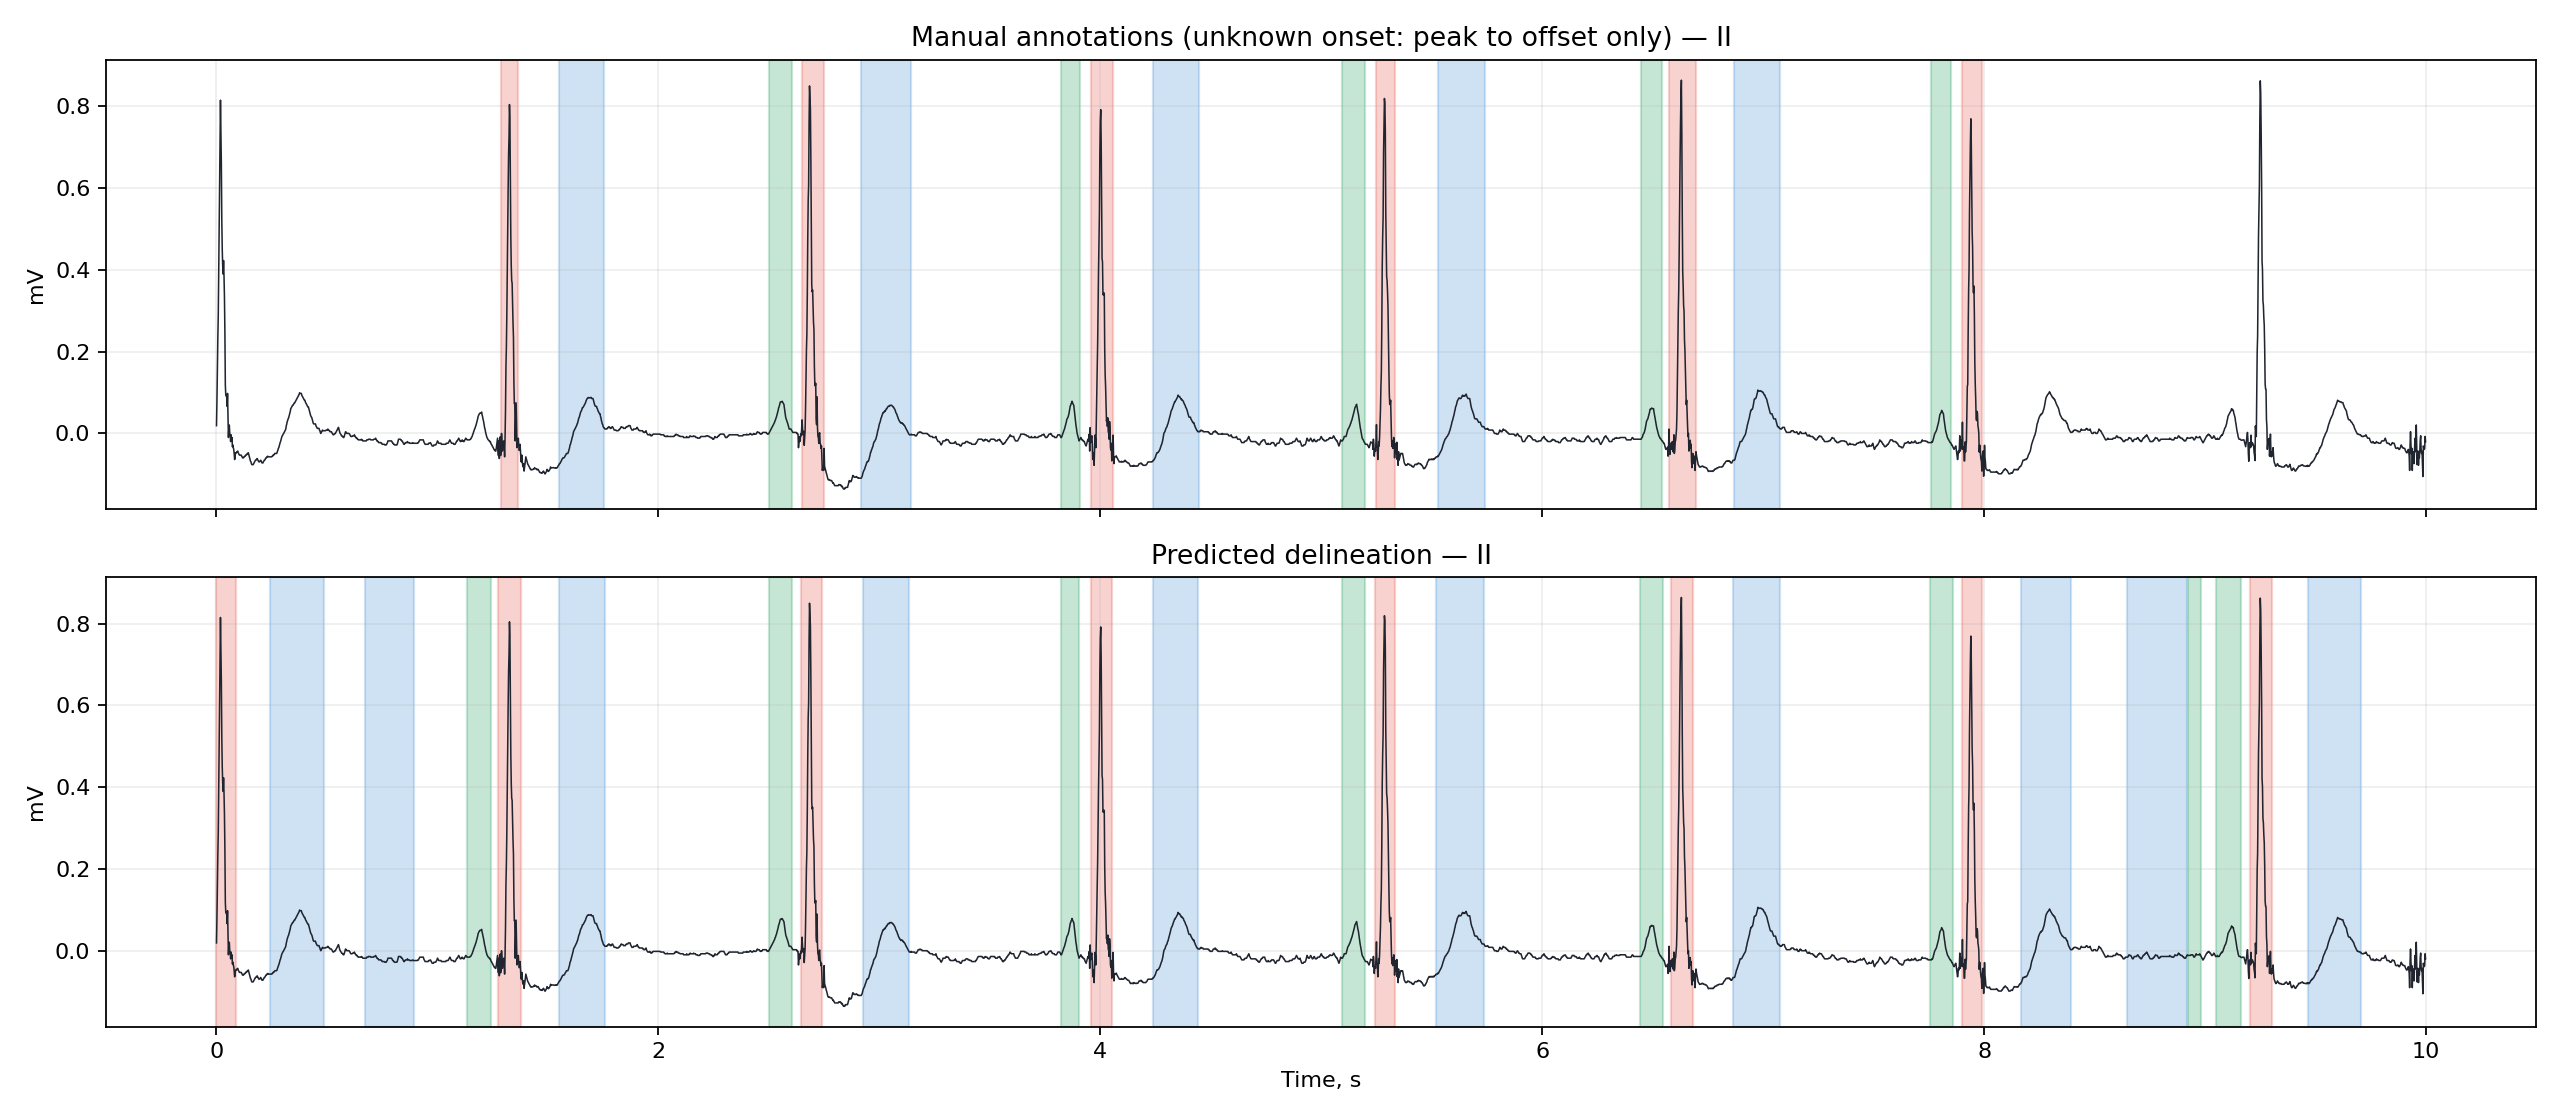

,wave,onset,peak,offset,confidence,source,lead,duration_ms,onset_s,offset_s,onset_abs,peak_abs,offset_abs,qrs_ge_120
0,QRS,2,12,42,0.708176,predicted,I,80.0,0.004,0.084,2,12,42,False
1,T,108,186,240,0.880597,predicted,I,264.0,0.216,0.480,108,186,240,NaN
2,T,330,452,460,0.801345,predicted,I,260.0,0.660,0.920,330,452,460,NaN
3,P,568,604,626,0.944510,predicted,I,116.0,1.136,1.252,568,604,626,NaN
4,QRS,642,666,682,0.964991,predicted,I,80.0,1.284,1.364,642,666,682,False
5,T,778,842,880,0.977991,predicted,I,204.0,1.556,1.760,778,842,880,NaN
6,P,1252,1284,1304,0.964003,predicted,I,104.0,2.504,2.608,1252,1284,1304,NaN
7,QRS,1324,1346,1362,0.944389,predicted,I,76.0,2.648,2.724,1324,1346,1362,False
8,T,1458,1520,1566,0.980982,predicted,I,216.0,2.916,3.132,1458,1520,1566,NaN
9,P,1910,1940,1960,0.957664,predicted,I,100.0,3.820,3.920,1910,1940,1960,NaN


,probability,threshold,flag
AF,0.001722,0.65,False
PVC,0.004701,0.5,False
SVEB,0.008224,0.1,False
AVB1,0.003112,0.05,False
AVB2,0.04049,0.5,False
AVB3,0.016345,0.5,False
AVB,0.008757,0.35,False
IVCD,0.054377,0.7,False


In [10]:
from ecg_project.workflows.analysis import analyze
from ecg_project.data.io import load_record
RECORD='LUDB/1.hea'
LEAD='II'
START=0
DURATION=10
PREVIEW=Path('reports/notebook_preview')
analyze(RECORD,output=str(PREVIEW),lead=LEAD,start_seconds=START,duration_seconds=DURATION)
from IPython.display import Image,display
display(Image(filename=str(PREVIEW/'delineation.png')))
intervals=pd.read_csv(PREVIEW/'intervals_predicted.csv')
display(intervals.head(12))
display(pd.DataFrame(read(PREVIEW/'analysis.json')['record_predictions']).T)


При доступном ipywidgets следующий блок даёт переключатель отведения. На удалённом Jupyter может потребоваться включить поддержку widgets; обычный график выше работает независимо.

In [11]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    leads=load_record(RECORD).leads
    dropdown=widgets.Dropdown(options=leads,value=LEAD,description='Lead')
    button=widgets.Button(description='Обновить график')
    preview_output=widgets.Output()
    def redraw(_):
        with preview_output:
            clear_output(wait=True)
            analyze(RECORD,output=str(PREVIEW),lead=dropdown.value,start_seconds=START,duration_seconds=DURATION)
            display(Image(filename=str(PREVIEW/'delineation.png')))
    button.on_click(redraw)
    display(widgets.HBox([dropdown,button]),preview_output)
except ImportError:
    print('ipywidgets не установлен; используйте параметры предыдущей ячейки')


Output()

## 10. Итоговая аналитика: ablation, per-class, confusion и PR
Новые модели оценены только на validation. Таблицы record AUROC и beat F1 относятся к разным задачам. F1 по найденным сокращениям и end-to-end F1 различаются; последний учитывает ошибки детектора.

In [12]:
rows=[]
for directory in ['artifacts/representation_experiments','artifacts/context_experiments']:
    p=Path(directory)/'metrics.json'
    if p.exists():
        for model,r in read(p).items():
            for c in ['N','S','V','F']:
                rows.append({'model':model,'class':c,'end_to_end_F1':r['validation'][c]['end_to_end_f1']})
if rows:
    table=pd.DataFrame(rows).pivot(index='model',columns='class',values='end_to_end_F1')
    display(table);table.plot.bar(figsize=(12,4));plt.ylim(0,1);plt.ylabel('Validation F1');plt.tight_layout();plt.show()
for p in [Path('artifacts/founder_experiments/metrics.json'),RUN_DIR/'founder_full'/'best_metrics.json']:
    if p.exists():
        result=read(p)
        if 'per_class' in result: display(pd.DataFrame(result['per_class']).T)
        else: display(pd.DataFrame({k:v['per_class'] for k,v in result.items()}).map(lambda v:v.get('auroc') if isinstance(v,dict) else v))


class,F,N,S,V
model,,,,
context_balanced,0.000000,0.945850,0.460993,0.573059
context_natural,0.000000,0.945498,0.385542,0.627141
context_sqrt,0.000000,0.945577,0.432234,0.599876
fusion_sqrt,0.000000,0.950946,0.172131,0.633438
masked_bert,0.190476,0.959316,0.141667,0.691865
masked_bert_latent_hgb,0.102564,0.958023,0.057416,0.738037
masked_frozen_latent_hgb,0.000000,0.962411,0.376923,0.695716
pca_latent_hgb,0.000000,0.945672,0.307692,0.532240
scratch_bert,0.153846,0.957582,0.436620,0.700468


C:\Users\user\AppData\Local\Temp\ipykernel_7052\2349380026.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  display(table);table.plot.bar(figsize=(12,4));plt.ylim(0,1);plt.ylabel('Validation F1');plt.tight_layout();plt.show()


,lead_I_intervals,founder_frozen,founder_frozen_intervals,founder_finetuned_last_stage
AF,0.983795,0.981521,0.987065,0.991969
AVB,0.850486,0.874595,0.873261,0.850581
IVCD,0.802431,0.824675,0.824809,0.841825


In [13]:
from sklearn.metrics import confusion_matrix,PrecisionRecallDisplay
MODEL_RUN=Path('artifacts/representation_experiments')
files=sorted(MODEL_RUN.glob('scratch_bert_*.npz'))
truth=[];prob=[]
manifest=read('artifacts/beat_features_qt/manifest.json')
valid_ids={r['record'] for r in manifest if r['split']=='valid'}
for p in files:
    record=p.stem.removeprefix('scratch_bert_')
    if record not in valid_ids: continue
    with np.load('artifacts/beat_features_qt/'+record+'.npz') as z: y=z['labels']
    with np.load(p) as z: pr=z['probability']
    known=y>=0;truth.extend(y[known]);prob.extend(pr[known])
if truth:
    truth=np.asarray(truth);prob=np.asarray(prob);cm=confusion_matrix(truth,prob.argmax(1),labels=range(5))
    fig,axs=plt.subplots(1,2,figsize=(12,4))
    axs[0].imshow(cm/np.maximum(cm.sum(1,keepdims=True),1),vmin=0,vmax=1,cmap='Blues')
    axs[0].set(xticks=range(5),yticks=range(5),xticklabels=list('NSVFQ'),yticklabels=list('NSVFQ'),xlabel='Prediction',ylabel='Reference',title='Matched detections only')
    for c in [1,2]: PrecisionRecallDisplay.from_predictions(truth==c,prob[:,c],name='NSVFQ'[c],ax=axs[1])
    plt.tight_layout();plt.show()
for p in RUN_DIR.glob('*/history.json'):
    h=pd.DataFrame(read(p))
    if not h.empty: display(h.tail(4))


C:\Users\user\AppData\Local\Temp\ipykernel_7052\864412654.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout();plt.show()


,stage,epoch,loss,seconds,valid_score
0,pretrain,1,1.071181,4.599844,NaN
1,finetune,1,1.945151,4.859201,0.209307


## 11. Что сохранять после обучения
Скопируйте папку run целиком: config, latest/best checkpoint, tokens, validation predictions, history, run.json. Для BERT нужны также соответствующий разметчик и спецификация признаков. Для ECGFounder — исходный net1d.py и веса/полный best.pt. Проверяйте отсутствие test в тренировочном manifest. Не объявляйте клиническую готовность по пилоту; форма ФП и критичность блокады требуют клинических данных. Подробный текущий статус — CONTINUATION.md.